# Później to uzupełnie

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
import scipy.signal as signal

## Wprowadzenie danych

In [2]:
data_string = """
90 1,244 57 1,750
89 1,008 56 1,845
88 0,777 55 1,915
87 0,490 54 1,951
86 0,205 53 1,945
85 0,182 52 1,914
84 0,475 51 1,852
83 0,753 50 1,770
82 1,037 49 1,622
81 1,270 48 1,445
80 1,459 47 1,238
79 1,607 46 1,000
78 1,727 45 0,711
77 1,810 44 0,543
76 1,864 43 0,315
75 1,882 42 0,395
74 1,876 41 0,671
73 1,834 40 0,940
72 1,750 39 1,169
71 1,645 38 1,385
70 1,510 37 1,570
69 1,328 36 1,730
68 1,115 35 1,842
67 0,886 34 1,975
66 0,633 33 1,942
65 0,370 32 1,945
64 0,135 31 1,916
63 0,268 30 1,840
62 0,510 29 1,700
61 0,995 28 1,555
60 1,232 27 1,480
59 1,448 26 1,320
58 1,606 25 1,165
"""

lines = [line.strip() for line in data_string.strip().split('\n') if line.strip()]

processed_data = []
for line in lines:
    parts = line.split()

    col1 = int(parts[0])
    col2 = float(parts[1].replace(',', '.'))
    processed_data.append([col1, col2])

    col3 = int(parts[2])
    col4 = float(parts[3].replace(',', '.'))
    processed_data.append([col3, col4])

data_array = np.array(processed_data)

sort_idx = np.argsort(data_array[:, 0])
l_800hz = data_array[sort_idx, 0]
U_800hz = data_array[sort_idx, 1]

strzalki_1khz = np.array([79, 62, 45, 27])
wezly_1khz = np.array([87, 70, 53, 36])
strzalki_15khz = np.array([85, 74, 63, 52, 41, 30])
wezly_15khz = np.array([90, 79, 68, 57, 46, 35])
strzalki_2khz = np.array([88, 79, 71, 62, 53, 45, 36, 28])
wezly_2khz = np.array([83, 75, 66, 58, 49, 41, 32])
strzalki_25khz = np.array([89, 82, 75, 68, 61, 55, 48, 41, 34, 27])
wezly_25khz = np.array([86, 79, 72, 65, 58, 51, 44, 37, 30])

## Część Pierwsza - obliczenia i regresja

In [3]:
max_ind = signal.argrelextrema(U_800hz, np.greater, order=2)[0]
min_ind = signal.argrelextrema(U_800hz, np.less, order=2)[0]

strzalki_l = l_800hz[max_ind]
strzalki_U = U_800hz[max_ind]

wezly_l = l_800hz[min_ind]
wezly_U = U_800hz[min_ind]

mean_max = np.mean(strzalki_U)
mean_min = np.mean(wezly_U)

distances = np.diff(wezly_l)
half_wavelength_avg = np.mean(distances)
wavelength = 2 * half_wavelength_avg

## Część Pierwsza - wykresy

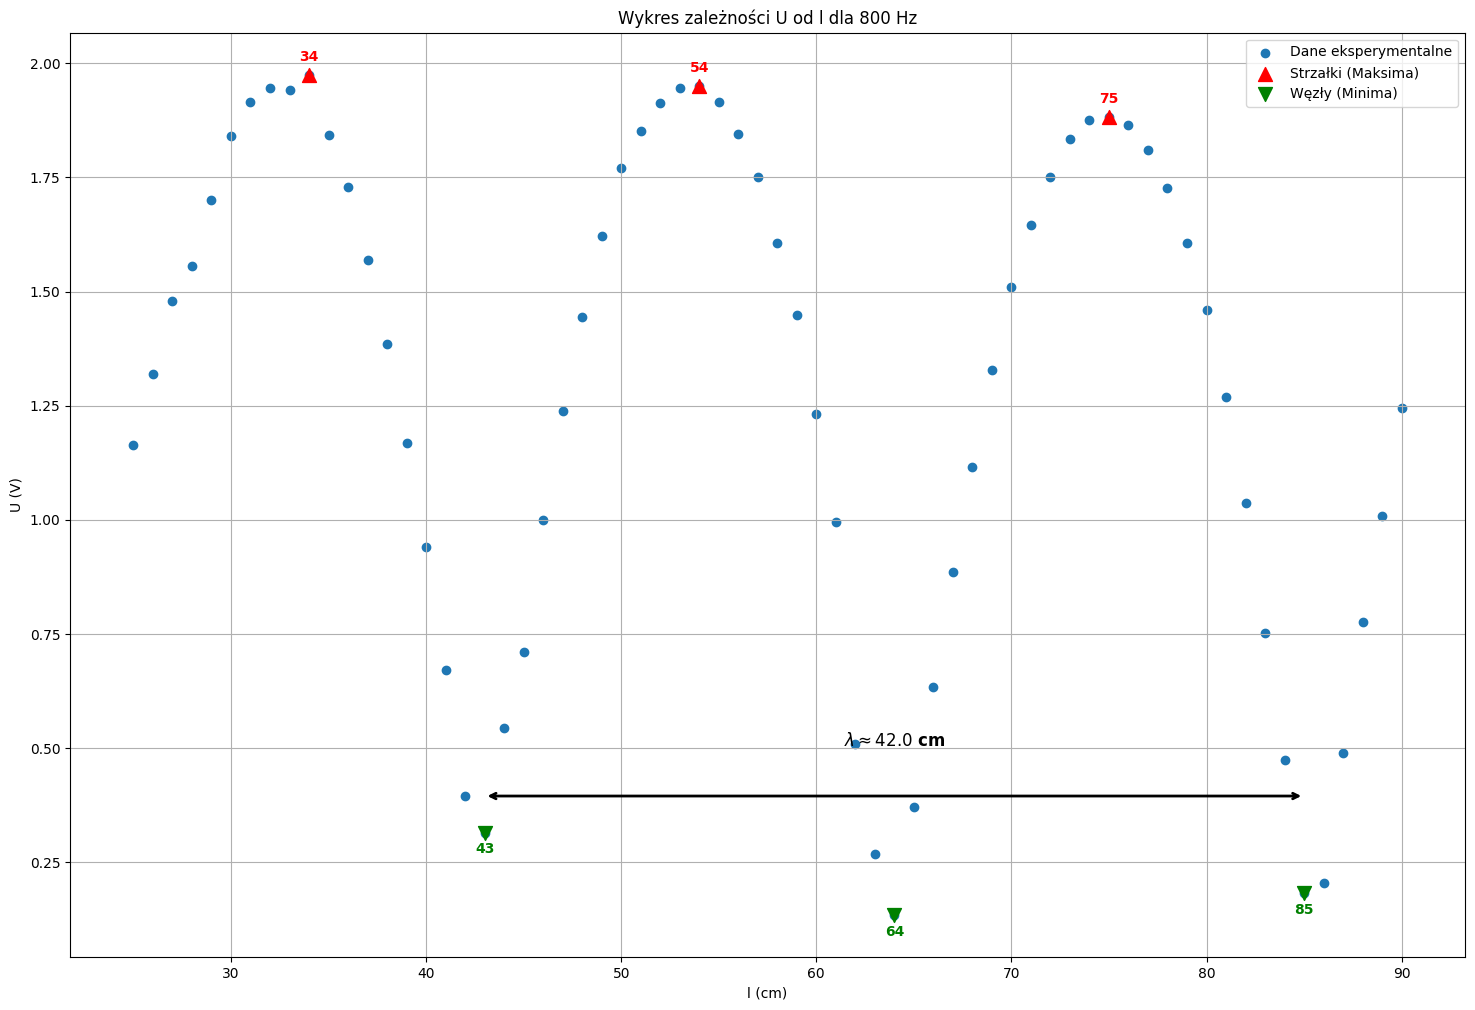

In [5]:
plt.figure(figsize=(18, 12))
plt.scatter(l_800hz, U_800hz, label='Dane eksperymentalne')
# Amplituda
# plt.plot([list(U_800hz).index(min(U_800hz))+15, list(U_800hz).index(min(U_800hz))+15], [(min(U_800hz)+max(U_800hz))/2, max(U_800hz)], 'r--', label='Amplituda')
# Zaznaczenie Strzałek (Maksima)
plt.scatter(strzalki_l, strzalki_U, color='red', s=100, marker='^', label='Strzałki (Maksima)', zorder=5)
for x, y in zip(strzalki_l, strzalki_U):
    plt.annotate(f'{int(x)}', (x, y), textcoords="offset points", xytext=(0,10), ha='center', color='red', fontweight='bold')

# Zaznaczenie Węzłów (Minima)
plt.scatter(wezly_l, wezly_U, color='green', s=100, marker='v', label='Węzły (Minima)', zorder=5)
for x, y in zip(wezly_l, wezly_U):
    plt.annotate(f'{int(x)}', (x, y), textcoords="offset points", xytext=(0,-15), ha='center', color='green', fontweight='bold')

# Wybieramy x gdzieś pośrodku zakresu, np. średnia z położeń
x_center = np.mean(l_800hz)
# Znajdźmy najbliższe maksimum do środka, żeby strzałka była reprezentatywna
closest_max_idx = np.abs(strzalki_l - x_center).argmin()
target_x = strzalki_l[closest_max_idx]
target_y_max = strzalki_U[closest_max_idx]
# Odpowiednie minimum (interpolowane lub średnie)
target_y_min = mean_min

# Rysujemy strzałkę oznaczającą "Amplitudę (międzyszczytową)" lub od zera?
# Zazwyczaj amplituda to A w sin(x). Tutaj sygnał to U.
# Narysujmy linię pionową pokazującą pełną rozpiętość sygnału (Peak-to-Peak) w miejscu maksimum
# plt.annotate(
#     '', xy=(target_x, target_y_max), xytext=(target_x, target_y_min),
#     arrowprops=dict(arrowstyle='<->', color='purple', lw=2)
# )
# plt.text(target_x + 1, (target_y_max + target_y_min)/2, f'Amplituda', color='purple', va='center')

if len(wezly_l) >= 3:
    x_start = wezly_l[0]
    x_end = wezly_l[2]
    y_pos = max(U_800hz) * 0.2 # Rysujemy trochę nad osią X, żeby było czytelnie

    # Strzałka wymiarowa
    plt.annotate(
        '', xy=(x_start, y_pos), xytext=(x_end, y_pos),
        arrowprops=dict(arrowstyle='<->', color='black', lw=2)
    )
    # Tekst
    plt.text((x_start + x_end)/2, y_pos + 0.1, f'$\\lambda \\approx {wavelength:.1f}$ cm',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Wykres zależności U od l dla 800 Hz')
plt.xlabel('l (cm)')
plt.ylabel('U (V)')
plt.legend()
plt.grid()
plt.show()